# Proyecto en Telecomunicaciones: Identificar operadores ineficaces

### Descripcion del proyecto

El servicio de telefonía virtual CallMeMaybe está desarrollando una nueva función que brindará a los supervisores y las supervisores información sobre los operadores menos eficaces. Se considera que un operador es ineficaz si tiene una gran cantidad de llamadas entrantes perdidas (internas y externas) y un tiempo de espera prolongado para las llamadas entrantes. Además, si se supone que un operador debe realizar llamadas salientes, un número reducido de ellas también será un signo de ineficacia.

**OBJETIVO DEL PROYECTO**: Probar la eficacia de la nueva funcion. Identificar operadores ineficaces y mediante una prueba de hipotesis estadistica comprobar la clasificacion de operadores.

### Descripcion de los datos

Los datasets contienen información sobre el uso del servicio de telefonía virtual CallMeMaybe. Sus clientes son organizaciones que necesitan distribuir gran cantidad de llamadas entrantes entre varios operadores, o realizar llamadas salientes a través de sus operadores. Los operadores también pueden realizar llamadas internas para comunicarse entre ellos. Estas llamadas se realizan a través de la red de CallMeMaybe.

El dataset comprimido `telecom_dataset_us.csv` contiene las siguientes columnas:

- `user_id`: ID de la cuenta de cliente
- `date`: fecha en la que se recuperaron las estadísticas
- `direction`: "dirección" de llamada (`out` para saliente, `in` para entrante)
- `internal`: si la llamada fue interna (entre los operadores de un cliente o clienta)
- `operator_id`: identificador del operador
- `is_missed_call`: si fue una llamada perdida
- `calls_count`: número de llamadas
- `call_duration`: duración de la llamada (sin incluir el tiempo de espera)
- `total_call_duration`: duración de la llamada (incluido el tiempo de espera)

El conjunto de datos `telecom_clients_us.csv` tiene las siguientes columnas:

- `user_id`: ID de usuario/a
- `tariff_plan`: tarifa actual de la clientela
- `date_start`: fecha de registro de la clientela



## Parte 1. Abrir archivos de datos y revisar informacion general de su contenido

Los archivos `telecom_dataset_us.csv` y `telecom_clients_us.csv` contienen datos sobre las llamadas de los operadores y los clientes respectivamente. Tenemos que:
- Cargar los datos en un Jupyter Notebook y revisar su estructura usando Python y la libreria pandas.
- Mediente el metodo `info()` revisar la estructura de las tablas, tamaño y los datos que contienen.
- Usando `head()` revisar las primeras filas de los datasets para tener una idea mas clara de la infomacion que contienen y como debemos procesar los datos.
- Mediante el metodo `describe()` podemos obtener estadisticas descriptivas generales como la media, desviacion estandar, minimos y maximos.

### 1.1 Importar librerias y cargar datos

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import datetime as dt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st

In [2]:
# Leer y cargar sets de datos
clients_data = pd.read_csv('datasets/telecom_clients.csv')
telecom_data = pd.read_csv('datasets/telecom_dataset_new.csv')

### 1.2 Revisar y estudiar los datos

In [3]:
# Revisar estructura del dataset con info()
telecom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [4]:
# Revisar estructura del dataset con info()
clients_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [5]:
# Mostrar primeras filas del dataset
telecom_data.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [6]:
# Cuales son las fechas minima y maxima del dataset telecom_dataset
print(f"Fecha inicial de los datos: {telecom_data['date'].min()}")
print(f"Fecha final de los datos: {telecom_data['date'].max()}")

Fecha inicial de los datos: 2019-08-02 00:00:00+03:00
Fecha final de los datos: 2019-11-28 00:00:00+03:00


In [7]:
# Mostrar primeras filas del dataset
clients_data.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [8]:
# Cuales son las fechas minima y maxima del dataset clients_data
print(f"Fecha inicial de los datos: {clients_data['date_start'].min()}")
print(f"Fecha final de los datos: {clients_data['date_start'].max()}")

Fecha inicial de los datos: 2019-08-01
Fecha final de los datos: 2019-10-31


In [9]:
# Estadisticas descriptivas del dataset telecom_dataset
telecom_data.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


In [10]:
# Estadisticas descriptivas del dataset clients_data
clients_data.describe()

,user_id
count,732.000000
mean,167431.927596
std,633.810383
min,166373.000000
25%,166900.750000
50%,167432.000000
75%,167973.000000
max,168606.000000


### === Observaciones iniciales de los datos ===

Al revisar el dataset `telecom_data` vemos que esencialmente contiene informacion sobre las llamadas de los operadores. Tenemos informacion sobre llamadas entrantes y salientes, llamadas perdidas, conteo de llamadas y duracion de llamadas. El dataset `clients_data` contiene un poco de informacion sobre los clientes como el plan tarifario que tienen activo en sus lineas y la fecha de inicio de su plan. Antes de comezar un analisis debemos limpiar los datos, sobre todo el dataset `telecom_data` parece tener datos faltantes y quiza tambien duplicados.

## Parte 2. Preparar los datos para analisis

### 2.1 Revisar duplicados y valores ausentes

Las columnas `'internal'` y `'operator_id'` del dataset `telecom_data` contienen valores ausentes, sin embargo tambien debemos revisar si existen duplicados. El dataset de `clients_data` parece estar limpio pero vale la pena revisar tambien.



In [11]:
# Verificar si existen filas duplicadas
print(f"Cantidad de filas duplicadas: {telecom_data.duplicated().sum()}")

Cantidad de filas duplicadas: 4900


In [12]:
# Procesar duplicados y guardar datos limpios en una nueva variable
telecom_dataset = telecom_data.drop_duplicates()

In [13]:
# Revisar cuantos valores ausentes existen
telecom_data.isna().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [14]:
# Procesar valores ausentes
telecom_data = telecom_data.dropna()

In [15]:
# Calcular porcentaje de datos restantes despues de procesar duplicados y ausentes
print("Datos restantes despues de procesar duplicados y ausentes: ", telecom_data.shape)
print()
print(f"Proporcion restante de datos despues de procesar duplicados y ausentes: { (45670/53902)*100:.2f}%")

Datos restantes despues de procesar duplicados y ausentes:  (45670, 9)

Proporcion restante de datos despues de procesar duplicados y ausentes: 84.73%


In [16]:
# Revisar duplicados del set de clientes
print(f"Cantidad de filas duplicadas: {clients_data.duplicated().sum()}")

Cantidad de filas duplicadas: 0


In [17]:
# Revisar valores ausentes del set de clientes
clients_data.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

### 2.2 Corregir tipos de datos

Podemos observar que algunas columnas en el dataset `telecom_data` tienen tipos de datos incorrectos. Especificamente la columna `'date'` podemos transformarla a tipo `datetime` y la columna `'internal'` a tipo `boolean`. El dataset `clients_data` tiene la columna `'date_start'` que tambien podriamos cambiar a tipo `datetime`. Vamos a corregir esos datos.

In [18]:
# Corregir tipos de datos a datetime del set telecom_data
telecom_data['date'] = pd.to_datetime(telecom_data['date'])

In [19]:
# Corregir tipo de dato a boolean del set telecom_data
telecom_data['internal'] = telecom_data['internal'].astype(bool)

In [20]:
# Corregir tipo de dato a datetime del set clients_data
clients_data['date_start'] = pd.to_datetime(clients_data['date_start'])

### 2.3 Enriquecer datos (agregar datos de utilidad)

En el dataset `telecom_data` podemos observar que existen dos columnas que calculan el tiempo de llamadas. El tiempo total (`'total_call_duration'`) y duracion de la llamada (`'call_duration'`) que es la duracion efectiva de la llamada sin contar el tiempo de espera. Podriamos calcular el tiempo de espera usando los datos de estas dos columnas, lo que seria de utilidad mas adelante puesto que el tiempo de espera es una metrica que usaremos para identificar operadores ineficaces. Otro datos que observamos es que las fechas inicial y final del dataset `telecom_data` son del mismo año (2019) desde agosto hasta noviembre, por lo que podria ser de utilidad separar los dias (fecha) y mes en columnas separadas. Esto mismo podria ser de utilidad para el set de clientes.

In [21]:
# Calcular tiempo de espera en una nueva columna
telecom_data['waiting_time'] = telecom_data['total_call_duration'] - telecom_data['call_duration']

In [22]:
# telecom_dataset

# Extraer dia en una columna separada
telecom_data['day'] = telecom_data['date'].dt.date

# Extraer mes en una columna separada
telecom_data['month'] = telecom_data['date'].dt.strftime('%Y-%m')

In [23]:
# Revisar cambios: mostrar primeras filas del dataset
telecom_data.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time,day,month
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,5,2019-08-05,2019-08
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,1,2019-08-05,2019-08
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,8,2019-08-05,2019-08
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25,25,2019-08-05,2019-08
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,False,2,3,29,26,2019-08-05,2019-08


In [24]:
# clients_data

# Extraer dia en una columna separada
clients_data['day'] = clients_data['date_start'].dt.date

# Extraer mes en una columna separada
clients_data['month'] = clients_data['date_start'].dt.strftime('%Y-%m')

In [25]:
# Revisar cambios: mostrar primeras filas del dataset
clients_data.head()

,user_id,tariff_plan,date_start,day,month
0,166713,A,2019-08-15,2019-08-15,2019-08
1,166901,A,2019-08-23,2019-08-23,2019-08
2,168527,A,2019-10-29,2019-10-29,2019-10
3,167097,A,2019-09-01,2019-09-01,2019-09
4,168193,A,2019-10-16,2019-10-16,2019-10


## Parte 3. Analisis Exploratorio

Nos interesa medir la eficacia de los operadores y para ello necesitamos medir su desempeño en cuanto a llamadas. Como nos insteresa el desempeño de cada operador seria conveniente agrupar por operadores y calcular las metricas de rendimiento que necesitamos. Sin embargo primero vamos a calcular estadisticas y graficas generales del dataset para entender la distribucion de los datos de manera general.

Puntos a revisar:

- Duracion general de llamadas: Histograma de duracion de llamadas, boxplot y observaciones.
- Tiempo de espera de llamadas: Histograma de tiempo de espera, boxplot y percentiles.
- Proporcion de llamadas perdidas vs atendidas.
- Proporcion de llamadas internas vs externas.
- Proporcion de llamadas entrantes vs salientes.

In [26]:
# Muestra de las primeras filas del dataset
telecom_data

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,waiting_time,day,month
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,5,2019-08-05,2019-08
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,1,2019-08-05,2019-08
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,8,2019-08-05,2019-08
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25,25,2019-08-05,2019-08
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,False,2,3,29,26,2019-08-05,2019-08
...,...,...,...,...,...,...,...,...,...,...,...,...
53896,168606,2019-11-10 00:00:00+03:00,out,True,957922.0,False,1,0,25,25,2019-11-10,2019-11
53897,168606,2019-11-10 00:00:00+03:00,out,True,957922.0,True,1,0,38,38,2019-11-10,2019-11
53898,168606,2019-11-11 00:00:00+03:00,out,True,957922.0,False,2,479,501,22,2019-11-11,2019-11
53899,168606,2019-11-15 00:00:00+03:00,out,True,957922.0,False,4,3130,3190,60,2019-11-15,2019-11


### 3.1 Duracion general de llamadas

La duracion de las llamadas es el tiempo efectivo que toma una llamada sin contar el tiempo de espera durante la llamada. Suponemos que una llamada de este tipo podria tomar entre 5 a 15 minutos o quizas mas dependiendo de otros factores.

In [27]:
# Estadisticas descriptivas de la duracion de llamadas
print(telecom_data['call_duration'].describe())
print()
print("Media de la duracion de llamadas: ", f"{telecom_data['call_duration'].mean():.2f} segundos")
print("Desviacion estandar de la duracion de llamadas: ", f"{telecom_data['call_duration'].std():.2f} segundos")
print("Llamada mas corta: ", f"{telecom_data['call_duration'].min()} segundos")
print("Llamada mas larga: ", f"{telecom_data['call_duration'].max()} segundos")

count     45670.000000
mean       1010.934399
std        4017.101865
min           0.000000
25%           0.000000
50%         107.000000
75%         774.000000
max      144395.000000
Name: call_duration, dtype: float64

Media de la duracion de llamadas:  1010.93 segundos
Desviacion estandar de la duracion de llamadas:  4017.10 segundos
Llamada mas corta:  0 segundos
Llamada mas larga:  144395 segundos


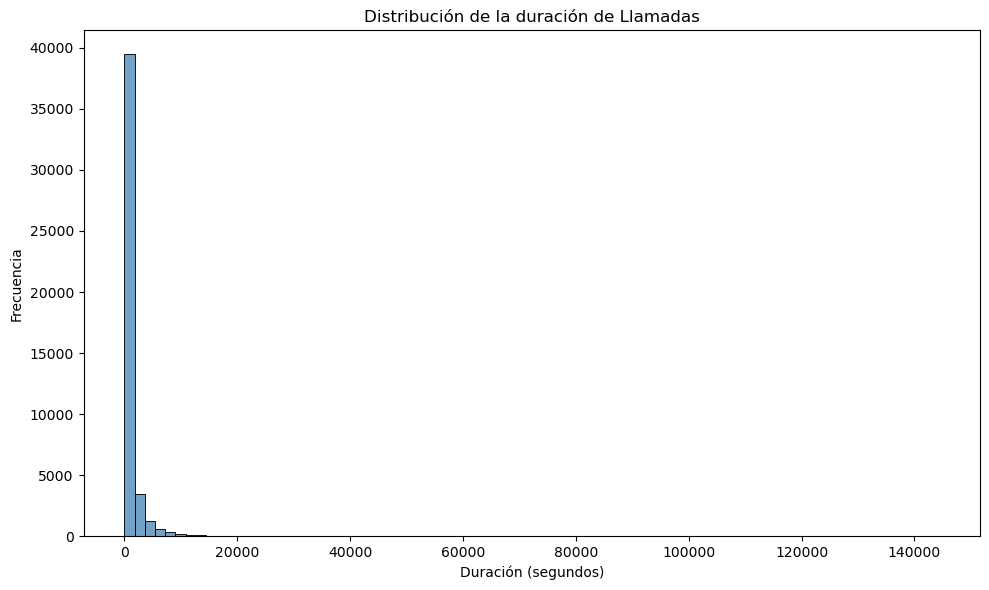

In [28]:
# Histograma de duración de llamadas
plt.figure(figsize=(10, 6))
sns.histplot(telecom_data['call_duration'], bins=80, kde=False, color='steelblue')
plt.title('Distribución de la duración de Llamadas')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

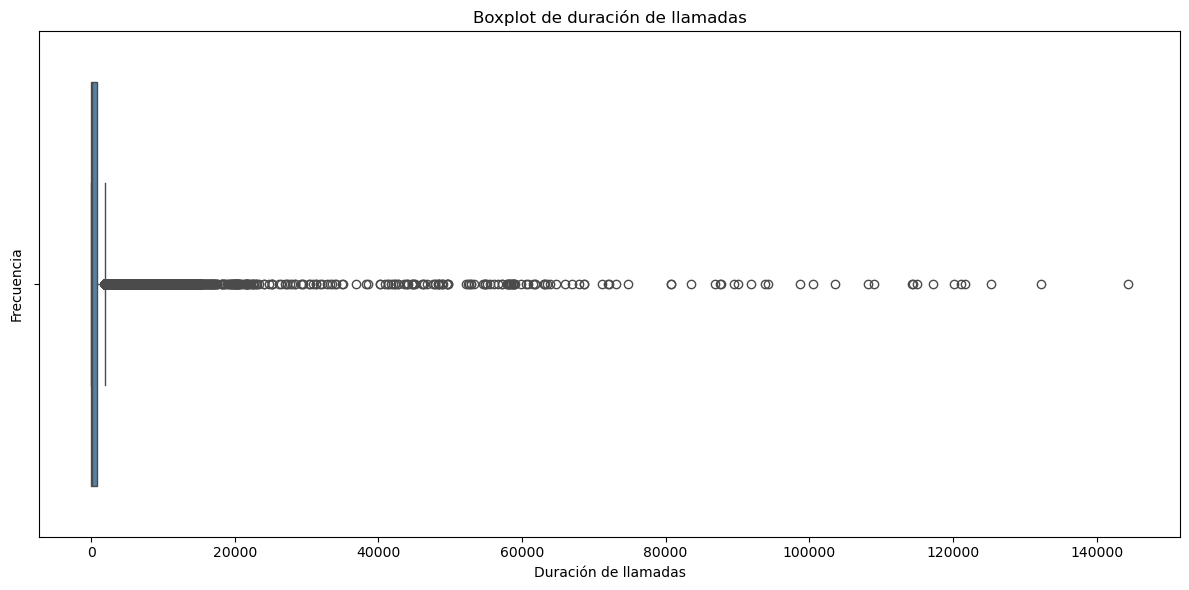

In [29]:
# Boxplot de duración de llamadas
plt.figure(figsize=(12, 6))
sns.boxplot(x=telecom_data['call_duration'], color='steelblue')
plt.title('Boxplot de duración de llamadas')
plt.xlabel('Duración de llamadas')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [29]:
# Calcular percentiles de duración de llamadas
percentil_95_duracion_de_llamadas = np.percentile(telecom_data['call_duration'], 95)
percentil_99_duracion_de_llamadas = np.percentile(telecom_data['call_duration'], 99)

# Imprimir resultados de percentiles
print(f"El percentil 95 de la duración de llamadas es: {percentil_95_duracion_de_llamadas:.2f} segundos")
print(f"El percentil 99 de la duración de llamadas es: {percentil_99_duracion_de_llamadas:.2f} segundos")

El percentil 95 de la duración de llamadas es: 4173.10 segundos
El percentil 99 de la duración de llamadas es: 11162.79 segundos


### === Observaciones de la duracion de las llamadas ===

Encontramos que la duracion promedio de una llamada en general (ya que estamos tomando encuenta llamadas internas, externas, entrantes y salientes) es de 1010.94 segundos, lo que en minutos es aproximadamente `1010.94 / 60 = 16.8 minutos`, es decir casi 17 minutos por llamada lo cual parece bastante para ser la media. Tambien encontramos que la llamada mas larga sin contar tiempo de espera es de 144,395 segundos que en horas es aproximadamente 40.1 horas lo cual es demasiado para una sola llamada. 

La distribucion de la duracion de las llamadas y el boxplot nos permiten ver que hay una cantidad considerable de llamadas que exceden los 5,000 segundos de duracion. Esta es la razon del porque la media sea de 16.8 minutos, pues estos valores extremos estan arrastrando la distribucion hacia la derecha.

Al calcular los percentiles (95 y 99) vemos que el 99% de llamadas esta por debajo de 10,988 segundos y el 95% esta por debajo de 4,161 segundos. 4161 segundos es poco mas de 1 hora lo cual todavia es una duracion por llamada considerablemente larga pero mas posible y razonable.

### 3.2 Tiempo de espera de llamadas

El tiempo de espera se relaciona directamente con la duracion de llamadas pues es el tiempo extra no utilizado efectivamente durante las llamadas. Por esta razon los resultados de estas metricas seran proporcionales a los de la duracion de llamadas.

In [30]:
# Estadisticas descriptivas del tiempo de espera
print(telecom_data['waiting_time'].describe())
print()
print("Media del tiempo de espera: ", f"{telecom_data['waiting_time'].mean():.2f} segundos")
print("Desviación estándar del tiempo de espera: ", f"{telecom_data['waiting_time'].std():.2f} segundos")
print("Tiempo de espera mínimo: ", f"{telecom_data['waiting_time'].min()} segundos")
print("Tiempo de espera máximo: ", f"{telecom_data['waiting_time'].max()} segundos")


count    45670.000000
mean       312.762601
std       1174.908171
min          0.000000
25%         19.000000
50%         60.000000
75%        221.000000
max      46474.000000
Name: waiting_time, dtype: float64

Media del tiempo de espera:  312.76 segundos
Desviación estándar del tiempo de espera:  1174.91 segundos
Tiempo de espera mínimo:  0 segundos
Tiempo de espera máximo:  46474 segundos


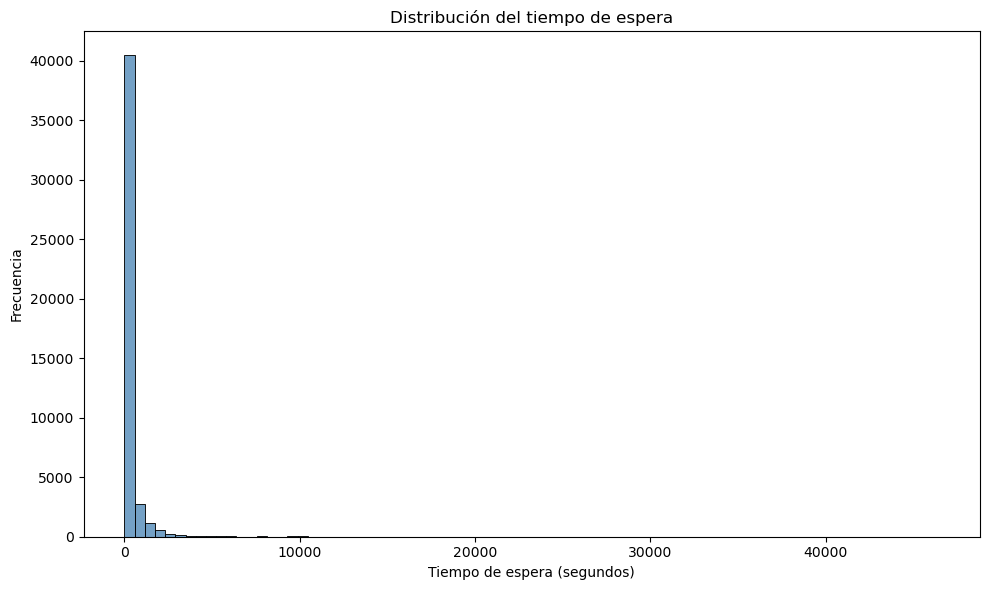

In [32]:
# Histograma de tiempo de espera
plt.figure(figsize=(10, 6))
sns.histplot(telecom_data['waiting_time'], bins=80, kde=False, color='steelblue')
plt.title('Distribución del tiempo de espera')
plt.xlabel('Tiempo de espera (segundos)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

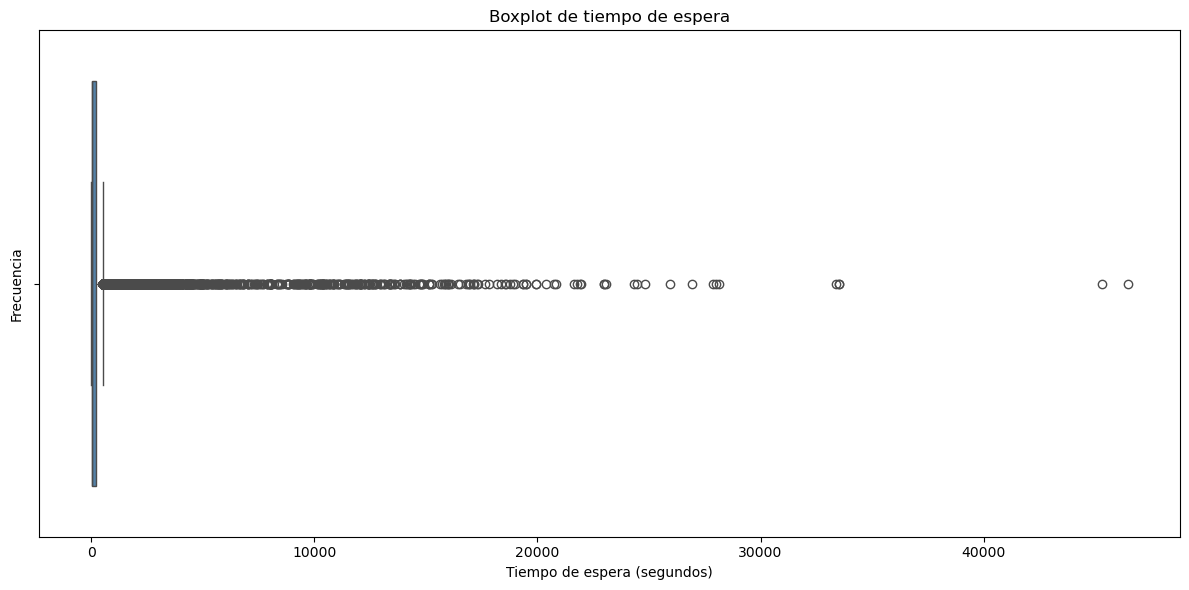

In [31]:
# Boxplot de tiempo de espera
plt.figure(figsize=(12, 6))
sns.boxplot(x=telecom_data['waiting_time'], color='steelblue')
plt.title('Boxplot de tiempo de espera')
plt.xlabel('Tiempo de espera (segundos)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [32]:
# Calcular percentiles de tiempo de espera
percentil_95_waiting_time = np.percentile(telecom_data['waiting_time'], 95)
percentil_99_waiting_time = np.percentile(telecom_data['waiting_time'], 99)

# Imprimir resultados de percentiles
print(f"El percentil 95 de tiempo de espera es: {percentil_95_waiting_time:.2f} segundos")
print(f"El percentil 99 de tiempo de espera es: {percentil_99_waiting_time:.2f} segundos")

El percentil 95 de tiempo de espera es: 1234.00 segundos
El percentil 99 de tiempo de espera es: 3530.24 segundos


### === Observaciones del tiempo de espera de llamadas ===

Similar a los resultados encontrados con la duracion de llamadas, los tiempos de espera son proporcionales. La media de tiempo de espera es de 312 segundos lo cual no es poco tiempo pero es razonable. Sin embargo encontramos que el valor mas alto es de 46,474 segundos, lo que es mas o menos 12.9 horas. El calculo de los percentiles 95 y 99 nos da valores de 1,234.5 segundos y 3,530.2 segundos respectivamente. Esto quiere decir que, en congruencia con la duracion de llamadas, existen tiempos de espera exageradamente altos.

### 3.3 Proporcion de llamadas perdidas, llamadas internas / externas y llamadas entrantes / salientes

In [33]:
# Analizar la proporción de llamadas perdidas vs atendidas
missed_calls_vs_attended_calls = telecom_data['is_missed_call'].value_counts().reset_index()
print("\n ==== Cantidad de llamadas perdidas vs atendidas ==== \n")
print(missed_calls_vs_attended_calls)

# Analizar proporcion de llamadas internas vs externas
internal_vs_external_calls = telecom_data['internal'].value_counts().reset_index()
print("\n ==== Cantidad de llamadas internas vs externas ==== \n")
print(internal_vs_external_calls)

# Analizar proporcion de llamadas entrantes vs salientes
incoming_vs_outgoing_calls = telecom_data['direction'].value_counts().reset_index()
print("\n ==== Cantidad de llamadas entrantes vs salientes ==== \n")
print(incoming_vs_outgoing_calls)


 ==== Cantidad de llamadas perdidas vs atendidas ==== 

   is_missed_call  count
0           False  30153
1            True  15517

 ==== Cantidad de llamadas internas vs externas ==== 

   internal  count
0     False  39861
1      True   5809

 ==== Cantidad de llamadas entrantes vs salientes ==== 

  direction  count
0       out  31717
1        in  13953


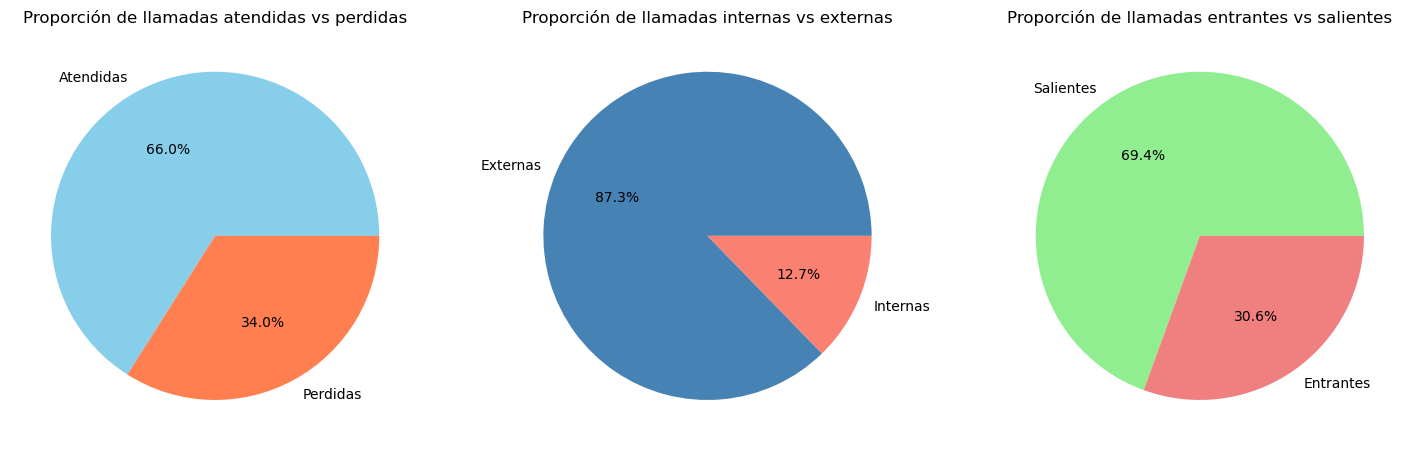

In [36]:
# Graficas
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 18))

# Grafico 1: Grafico circular de llamadas perdidas vs atendidas
g1_labels = ['Atendidas', 'Perdidas']
g1_sizes = missed_calls_vs_attended_calls['count']
g1_colors = ['skyblue', 'coral']

ax1.pie(g1_sizes, labels=g1_labels, colors=g1_colors, autopct='%1.1f%%')
ax1.set_title('Proporción de llamadas atendidas vs perdidas')

# Grafico 2: Grafico circular de llamadas internas vs externas
g2_labels = ['Externas', 'Internas']
g2_sizes = internal_vs_external_calls['count']
g2_colors = ['steelblue', 'salmon']

ax2.pie(g2_sizes, labels=g2_labels, colors=g2_colors, autopct='%1.1f%%')
ax2.set_title('Proporción de llamadas internas vs externas')

# Grafico 3: Grafico circular de llamadas entrantes vs salientes
g3_labels = ['Salientes', 'Entrantes']
g3_sizes = incoming_vs_outgoing_calls['count']
g3_colors = ['lightgreen', 'lightcoral']

ax3.pie(g3_sizes, labels=g3_labels, colors=g3_colors, autopct='%1.1f%%')
ax3.set_title('Proporción de llamadas entrantes vs salientes')

plt.show()

###  == Observaciones para las proporciones de llamadas ==

La proporcion de llamadas perdidas en general es de 34%, esto es 1 de cada 3 llamadas es una llamada perdida lo cual no parece poco. La proporcion de llamadas internas vs externas parace razonable. La gran mayoria de llamadas son externas un 87.3%, puesto que estas llamadas son con clientes, esta proporcion parace saludable. Finalmente las llamadas entrantes vs salientes, la proporcion es de 30.6%  para las llamadas entrantes. Puesto que los operadores deben realizar mas llamadas salientes esta proporcion tambien parece ser saludable.

### 3.4 Analisis por operadores

Ahora que hemos podido observar el dataset con mas detalle tenemos un mejor entendimiento sobre la distribucion de los datos y sus estadisticas. Para esta seccion vamos a analizar las metricas por operadores, es decir, vamos a agrupar los datos por `operador_id` y calcular el numero de llamadas entrantes perdidas por operador y el tiempo de espera en llamadas entrantes. Tambien vamos a revisar el numero de llamadas salientes por operador.

Tareas:

- Filtrar llamadas entrantes y llamadas salientes
- Determinar la proporcion de llamadas entrantes perdidas por operador
- Crear un histograma y grafico de dispersion para llamadas perdidas por operador
- Calcular el tiempo de espera promedio para cada operador
- Crear un histograma y grafico de dispersion para el tiempo de espera por operador 
- Calcular el volumen de llamadas salientes por operador
- Histograma de llamadas salientes y grafico de dispersion de llamadas salientes por operador
- Unir las tablas resultantes para crear un dataframe con metricas de rendimiento por operador

#### 3.4.1 Filtro para llamadas entrantes y salientes

In [37]:
# Crear un filtro para las llamadas entrantes
incoming_calls = telecom_data[telecom_data['direction'] == 'in']

# Crear un filtro para las llamadas salientes
outgoing_calls = telecom_data[telecom_data['direction'] == 'out']

#### 3.4.2 Determinar la proporcion de llamadas (entrantes) perdidas por operador

In [38]:
# Conteo de llamadas atendidas por operador
attended_calls_by_operator = incoming_calls[incoming_calls['is_missed_call'] == False].groupby('operator_id')['is_missed_call'].count().reset_index().rename(columns={'is_missed_call': 'attended_calls'})

# Conteo de llamadas perdidas por operador
missed_calls_by_operator = incoming_calls[incoming_calls['is_missed_call'] == True].groupby('operator_id')['is_missed_call'].count().reset_index().rename(columns={'is_missed_call': 'missed_calls'}).sort_values(by='missed_calls', ascending=False)

# Unir ambos dataframes para calcular la proporcion de llamadas perdidas por operador
calls_by_operator = pd.merge(attended_calls_by_operator, missed_calls_by_operator, on='operator_id', how='outer').fillna(0)

# Calcular la proporcion de llamadas perdidas por operador
calls_by_operator['missed_calls_proportion'] = (calls_by_operator['missed_calls'] / (calls_by_operator['attended_calls'] + calls_by_operator['missed_calls'])).round(2)

# Mostrar la proporcion de llamadas perdidas por operador ordenada de mayor a menor
print("\n ================ Llamadas perdidas / atendidas por operador ================ ")
print("\n ================================= Top 10 =================================== \n")
calls_by_operator.sort_values(by='missed_calls', ascending=False).head(10)


 ================ Llamadas perdidas / atendidas por operador ================ 

 ================================= Top 10 =================================== 



,operator_id,attended_calls,missed_calls,missed_calls_proportion
289,913942.0,61.0,29.0,0.32
22,885890.0,81.0,22.0,0.21
594,944216.0,42.0,21.0,0.33
21,885876.0,82.0,21.0,0.20
598,944226.0,39.0,15.0,0.28
570,940588.0,44.0,15.0,0.25
288,913938.0,70.0,14.0,0.17
596,944220.0,45.0,14.0,0.24
595,944218.0,41.0,12.0,0.23
575,940622.0,20.0,12.0,0.38


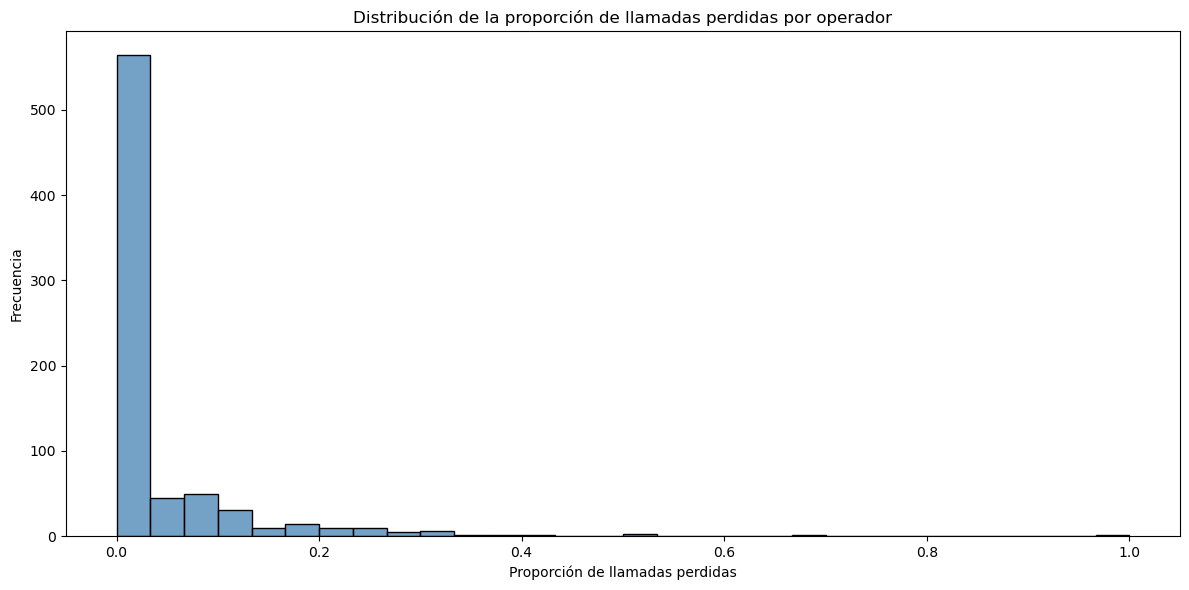

In [39]:
# Histograma de la proporcion de llamadas perdidas por operador
plt.figure(figsize=(12, 6))
sns.histplot(calls_by_operator['missed_calls_proportion'], bins=30, kde=False, color='steelblue')
plt.title('Distribución de la proporción de llamadas perdidas por operador')
plt.xlabel('Proporción de llamadas perdidas')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

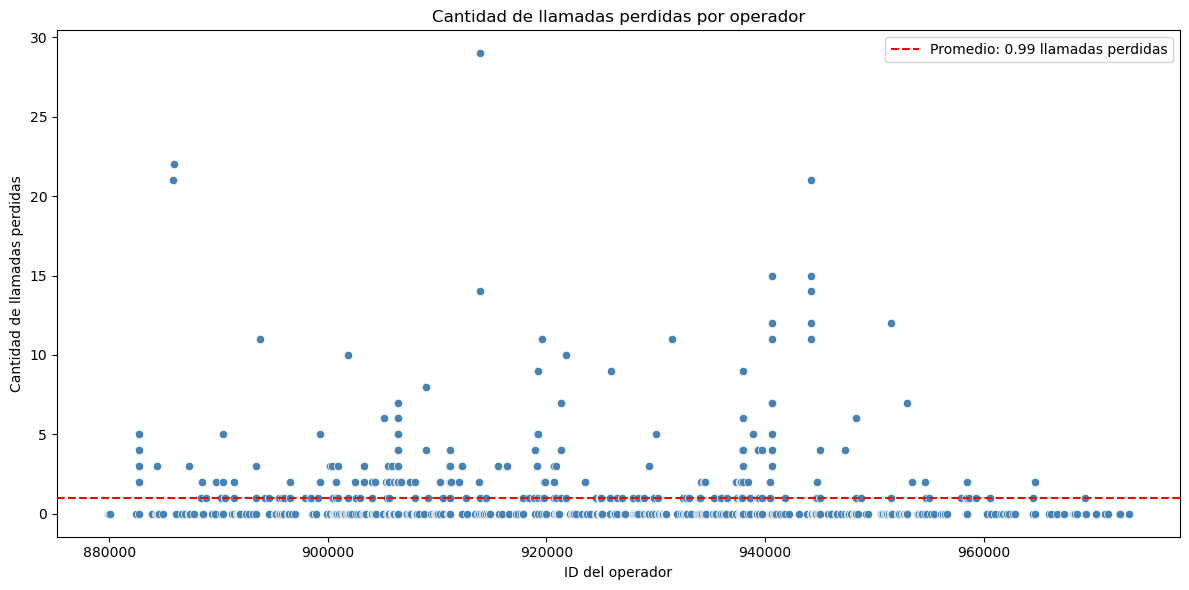

In [40]:
# Grafica de dispersión de la cantidad de llamadas perdidas por operador
plt.figure(figsize=(12, 6))
sns.scatterplot(x='operator_id', y='missed_calls', data=calls_by_operator, color='steelblue')

# Dibujar una linea horizontal para marcar el promedio de llamadas perdidas
average_missed_calls = calls_by_operator['missed_calls'].mean()
plt.axhline(average_missed_calls, color='red', linestyle='--', label=f'Promedio: {average_missed_calls:.2f} llamadas perdidas')
plt.legend()
plt.title('Cantidad de llamadas perdidas por operador')
plt.xlabel('ID del operador')
plt.ylabel('Cantidad de llamadas perdidas')
plt.tight_layout()
plt.show()

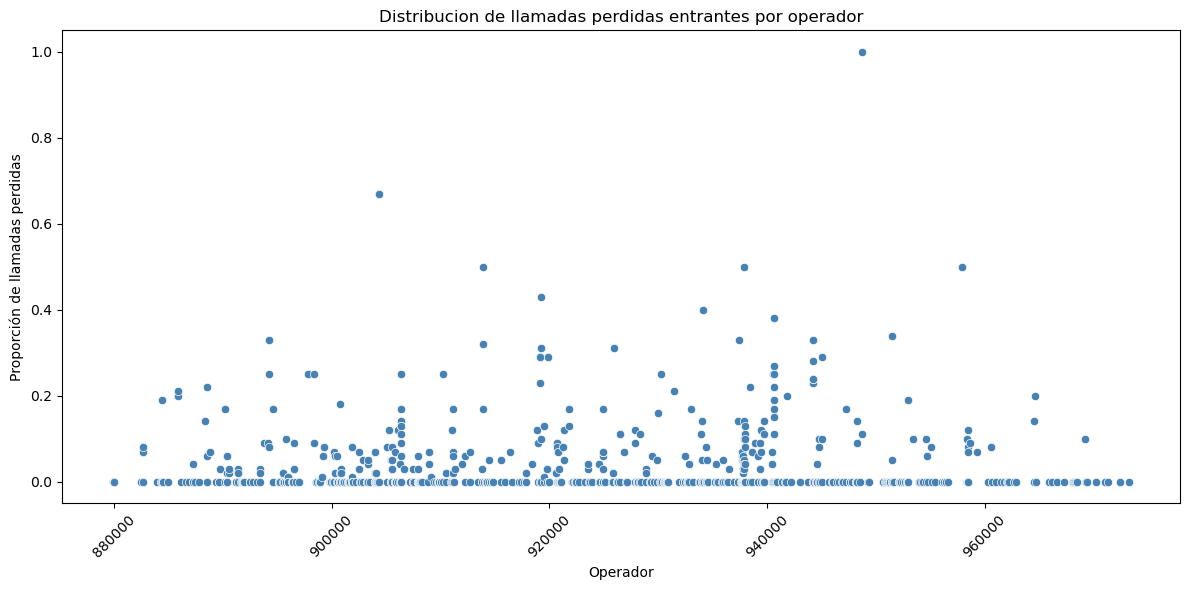

In [41]:
# Grafica de dispersion de llamadas perdidas entrantes por operador
plt.figure(figsize=(12, 6))
sns.scatterplot(data=calls_by_operator, x='operator_id', y='missed_calls_proportion', color='steelblue')
plt.title('Distribucion de llamadas perdidas entrantes por operador')
plt.xlabel('Operador')
plt.ylabel('Proporción de llamadas perdidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3.4.3 Tiempo de espera de llamadas entrantes por operador

In [42]:
# Analizar el tiempo de espera promedio por operador para llamadas entrantes
avg_waiting_time_by_operator = incoming_calls.groupby('operator_id')['waiting_time'].mean().reset_index().rename(columns={'waiting_time': 'avg_waiting_time'}).round(2).sort_values(by='avg_waiting_time', ascending=False)

# Unir ambos dataframes para analizar las metricas por operador
stats_by_operator = pd.merge(calls_by_operator, avg_waiting_time_by_operator, on='operator_id', how='outer').fillna(0)

# Mostrar metricas unidas
print(f"Promedio de tiempo de espera por operador: {avg_waiting_time_by_operator['avg_waiting_time'].mean():.2f} segundos")
print("\n ==================================== Metricas por operador =================================== \n")
stats_by_operator

Promedio de tiempo de espera por operador: 57.87 segundos

 ==================================== Metricas por operador =================================== 



,operator_id,attended_calls,missed_calls,missed_calls_proportion,avg_waiting_time
0,879896.0,23.0,0.0,0.0,26.91
1,879898.0,63.0,0.0,0.0,28.54
2,880020.0,8.0,0.0,0.0,7.25
3,880022.0,8.0,0.0,0.0,14.00
4,880026.0,19.0,0.0,0.0,7.89
...,...,...,...,...,...
749,971102.0,5.0,0.0,0.0,274.00
750,971354.0,2.0,0.0,0.0,42.00
751,972412.0,1.0,0.0,0.0,25.00
752,972460.0,2.0,0.0,0.0,4.00


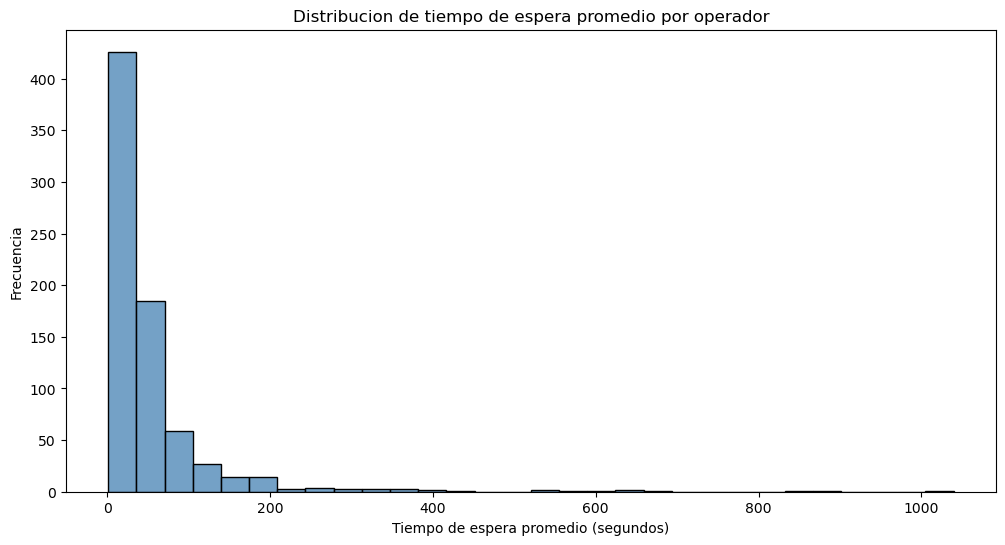

In [43]:
# Histograma de tiempo de espera promedio por operador
plt.figure(figsize=(12, 6))
sns.histplot(avg_waiting_time_by_operator['avg_waiting_time'], bins=30, kde=False, color='steelblue')
plt.title('Distribucion de tiempo de espera promedio por operador')
plt.xlabel('Tiempo de espera promedio (segundos)')
plt.ylabel('Frecuencia')
plt.show()

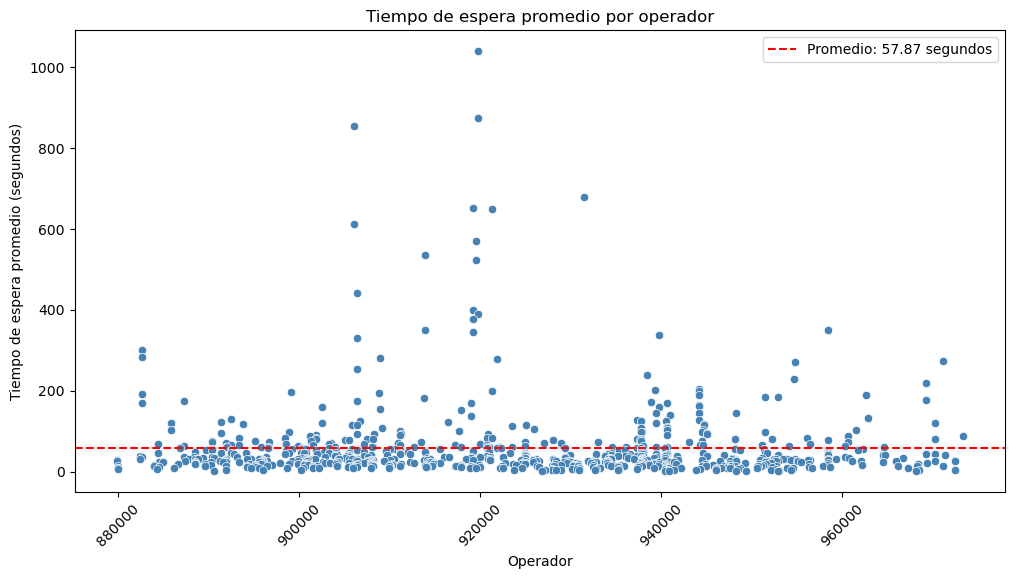

In [44]:
# Grafico de dispersion de tiempo de espera promedio por operador
plt.figure(figsize=(12, 6))
sns.scatterplot(data=avg_waiting_time_by_operator, x='operator_id', y='avg_waiting_time', color='steelblue')

# Dibujar una linea horizontal para marcar el promedio de tiempo de espera
average_waiting_time = avg_waiting_time_by_operator['avg_waiting_time'].mean()
plt.axhline(average_waiting_time, color='red', linestyle='--', label=f'Promedio: {average_waiting_time:.2f} segundos')
plt.legend()
plt.title('Tiempo de espera promedio por operador')
plt.xlabel('Operador')
plt.ylabel('Tiempo de espera promedio (segundos)')
plt.xticks(rotation=45)
plt.show()

#### 3.4.4 Volumen de llamadas salientes por operador

In [45]:
# Analizar el volumen (suma) de llamadas por operador para llamadas salientes
out_calls_count_by_operator = outgoing_calls.groupby('operator_id')['calls_count'].sum().reset_index().rename(columns={'calls_count': 'out_calls_count'})

# Unir dataframe a stats_by_operator
stats_by_operator = pd.merge(stats_by_operator, out_calls_count_by_operator, on='operator_id', how='outer').fillna(0)

# Mostrar metricas unidas
print(f"Promedio de llamadas salientes por operador: {out_calls_count_by_operator['out_calls_count'].mean():.2f}")
print("\n ==================================== Metricas por operador =================================== \n")
stats_by_operator

Promedio de llamadas salientes por operador: 758.89

 ==================================== Metricas por operador =================================== 



,operator_id,attended_calls,missed_calls,missed_calls_proportion,avg_waiting_time,out_calls_count
0,879896.0,23.0,0.0,0.0,26.91,1071.0
1,879898.0,63.0,0.0,0.0,28.54,7856.0
2,880020.0,8.0,0.0,0.0,7.25,46.0
3,880022.0,8.0,0.0,0.0,14.00,211.0
4,880026.0,19.0,0.0,0.0,7.89,2414.0
...,...,...,...,...,...,...
1087,972410.0,0.0,0.0,0.0,0.00,77.0
1088,972412.0,1.0,0.0,0.0,25.00,60.0
1089,972460.0,2.0,0.0,0.0,4.00,68.0
1090,973120.0,0.0,0.0,0.0,0.00,3.0


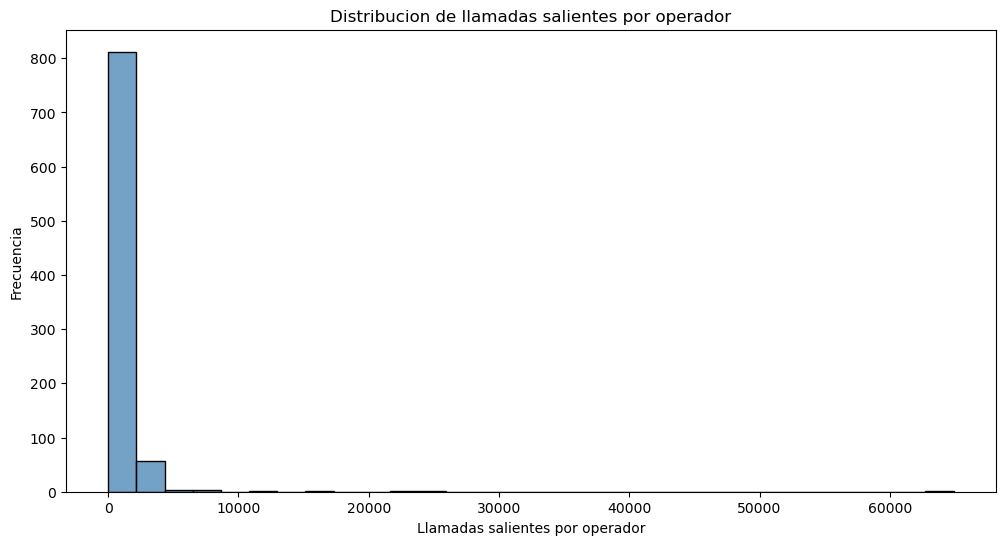

In [46]:
# Histograma de llamadas salientes por operador
plt.figure(figsize=(12, 6))
sns.histplot(out_calls_count_by_operator['out_calls_count'], bins=30, kde=False, color='steelblue')
plt.title('Distribucion de llamadas salientes por operador')
plt.xlabel('Llamadas salientes por operador')
plt.ylabel('Frecuencia')
plt.show()

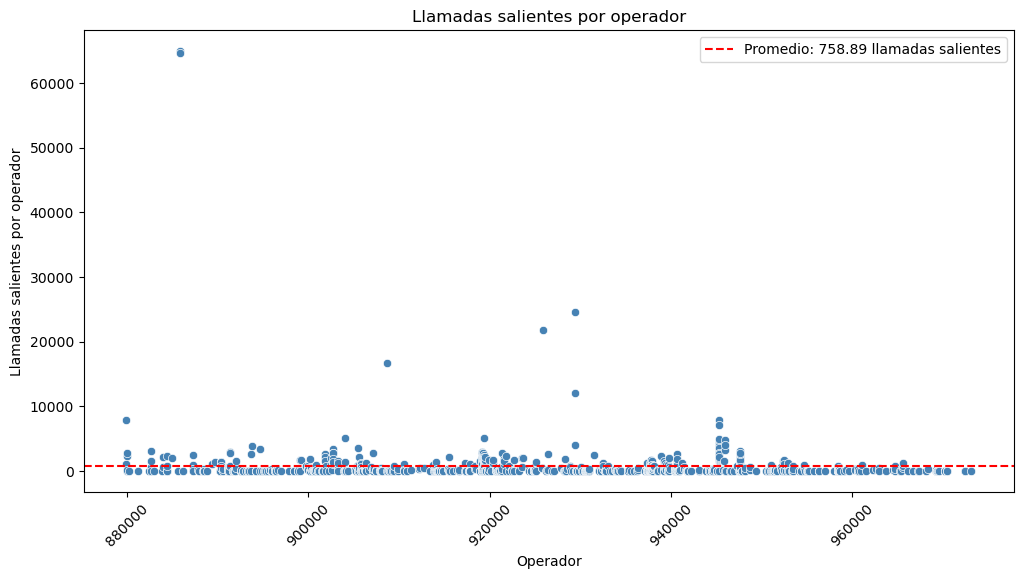

In [47]:
# Grafico de dispersion de las llamadas salientes por operador
plt.figure(figsize=(12, 6))
sns.scatterplot(data=out_calls_count_by_operator, x='operator_id', y='out_calls_count', color='steelblue')

# Dibujar una linea horizontal para marcar el promedio de llamadas salientes
average_out_calls_count = out_calls_count_by_operator['out_calls_count'].mean()
plt.axhline(average_out_calls_count, color='red', linestyle='--', label=f'Promedio: {average_out_calls_count:.2f} llamadas salientes')
plt.legend()
plt.title('Llamadas salientes por operador')
plt.xlabel('Operador')
plt.ylabel('Llamadas salientes por operador')
plt.xticks(rotation=45)
plt.show()

In [48]:
# Percentil 95 de llamadas salientes por operador
percentil_95_llamadas_salientes = np.percentile(out_calls_count_by_operator['out_calls_count'], 95)
print(f"El 95% de operadores tiene un volumen de llamadas salientes inferior a: {percentil_95_llamadas_salientes:.2f} llamadas")

El 95% de operadores tiene un volumen de llamadas salientes inferior a: 2616.65 llamadas


#### Top 5% de operadores con mayor volumen de llamadas salientes

In [49]:
# Filtrar operadores que superan el percentil 95 de llamadas salientes
top_5_percent_llamadas_salientes = stats_by_operator[stats_by_operator['out_calls_count'] > percentil_95_llamadas_salientes]

print("\n ========== Top 5 porciento de operadores con mayor volumen de llamadas salientes ========== \n")
top_5_percent_llamadas_salientes.sort_values('out_calls_count', ascending=False).head(10)


 ========== Top 5 porciento de operadores con mayor volumen de llamadas salientes ========== 



,operator_id,attended_calls,missed_calls,missed_calls_proportion,avg_waiting_time,out_calls_count
28,885876.0,82.0,21.0,0.20,101.94,64897.0
29,885890.0,81.0,22.0,0.21,120.34,64653.0
583,929428.0,0.0,0.0,0.00,0.00,24572.0
551,925922.0,20.0,9.0,0.31,105.21,21754.0
317,908640.0,0.0,0.0,0.00,0.00,16699.0
582,929426.0,0.0,0.0,0.00,0.00,12041.0
847,945286.0,0.0,0.0,0.00,0.00,7919.0
1,879898.0,63.0,0.0,0.00,28.54,7856.0
853,945302.0,0.0,0.0,0.00,0.00,7059.0
234,904016.0,25.0,2.0,0.07,38.70,5120.0


#### ¿Excluir o no a los operadores con un volumen de llamadas demasiado alto?

No estamos seguros si excluir a estos operadores que tienen un volumen de llamadas excesivamente alto y que estan arrastrando tanto la distribucion del volumen de llamadas al punto de arrastrar la media hacia un numero poco descriptivo para la mayoria. Sin embargo, dado que debemos evaluar a todos los operadores es mejor mantener todos los datos. Por lo tanto creemos que es mejor no excluir a los operadores con un volumen de llamadas muy alto.

In [50]:
# Filtrar el dataframe stats_by_operator para excluir al top 5% de operadores con muchas llamadas salientes
# stats_by_operator_standard = stats_by_operator[stats_by_operator['out_calls_count'] <= percentil_95_llamadas_salientes]

# Guardar el dataframe sin filtrar en una nueva variable para comparacion
stats_by_operator_standard = stats_by_operator

#### Tabla de Metricas de desempeño de operadores

In [51]:
# Metricas de desempeño de operadores excluyendo el top 5% de operadores con muchas llamadas salientes
print("\n ========================= Tabla de Metricas de desempeño de operadores ========================= \n")
stats_by_operator_standard


 ========================= Tabla de Metricas de desempeño de operadores ========================= 



,operator_id,attended_calls,missed_calls,missed_calls_proportion,avg_waiting_time,out_calls_count
0,879896.0,23.0,0.0,0.0,26.91,1071.0
1,879898.0,63.0,0.0,0.0,28.54,7856.0
2,880020.0,8.0,0.0,0.0,7.25,46.0
3,880022.0,8.0,0.0,0.0,14.00,211.0
4,880026.0,19.0,0.0,0.0,7.89,2414.0
...,...,...,...,...,...,...
1087,972410.0,0.0,0.0,0.0,0.00,77.0
1088,972412.0,1.0,0.0,0.0,25.00,60.0
1089,972460.0,2.0,0.0,0.0,4.00,68.0
1090,973120.0,0.0,0.0,0.0,0.00,3.0


## Parte 4. Definicion y clasificacion de operadores ineficaces

Ahora tenemos un dataframe con las metricas que necesitamos para evaluar el rendimiento de los operadores. Para resumir vamos listar a manera de diccionario de datos cada una de las metricas y una breve descripcion de la informacion que contienen.

Resumen de metricas de rendimiento:

- `operator_id`: el numero de id unico del operador.
- `attended_calls_count`: cantidad de llamadas entrantes atendidas o contestadas por operador.
- `missed_calls_count`: cantidad de llamadas entrantes perdidas o NO contestadas por operador.
- `missed_calls_proportion`: La proporcion porcentual de llamadas entrantes perdidas por operador.
- `avg_waiting_time`: Tiempo de espera promedio para las llamadas entrantes.
- `avg_calls_count`: Promedio de numero de llamadas salientes realizadas por operador. 

Ahora tenemos la tarea de como definir que un operador es ineficaz basado en las metricas que tenemos. Para ello primero debemos establecer umbrales para cada metrica a partir de la cual se considera ineficaz. Podemos establecer entonces lo siguientes criterios

Criterios:

- Criterio 1: Alta cantidad de llamadas entrantes perdidas
- Criterio 2: Tiempo de espera prolongado para llamadas entrantes
- Criterio 3: Bajo volumen de llamadas salientes realizadas

Tareas:

- Determinar umbrales de clasificacion de operadores
- Crear un funcion para clasificar operadores en eficaz si pasa los umbrales o ineficaz si esta por debajo de los umbrales.
- Un operador sera clasificado como ineficaz si esta por debajo de al menos un criterio de evaluacion.
- Aplicar la funcion para clasificar operadores.
- Grificar metricas de ambos grupos por separado.

#### 4.1 Determinar umbrales para clasificar un operador ineficaz

In [52]:
# Umbral de llamadas perdidas - Percentil 95 de la cantidad de llamadas perdidas por operador
missed_calls_threshold = np.percentile(stats_by_operator_standard['missed_calls'], 99)
print(f"Umbral de llamadas perdidas: {missed_calls_threshold:,.2f} llamadas perdidas")

Umbral de llamadas perdidas: 11.09 llamadas perdidas


In [53]:
# Umbral de tiempo de espera - Percentil 94 del tiempo de espera promedio por operador
waiting_time_threshold = np.percentile(stats_by_operator_standard['avg_waiting_time'], 95)
print(f"Umbral de tiempo de espera: {waiting_time_threshold:,.2f} segundos")

Umbral de tiempo de espera: 145.58 segundos


In [54]:
# Umbral de llamadas salientes - Percentil 99 del numero de llamadas salientes promedio por operador
out_calls_count_threshold = np.percentile(stats_by_operator_standard['out_calls_count'], 50)
print(f"Umbral de llamadas salientes: {out_calls_count_threshold:.2f} llamadas salientes")

Umbral de llamadas salientes: 36.50 llamadas salientes


#### 4.2 Crear un funcion para clasificar operadores en ineficaz o eficaz

Un operador debe cumplir al menos uno de los criterios antes establecidos para ser etiquetado como ineficaz, de lo contrario sera etiquetado como eficaz.

In [55]:
def classify_operator_efficiency(df, missed_calls_threshold, waiting_time_threshold, out_calls_count_threshold):
    """
    Clasifica a los operadores como 'ineficaz' o 'eficaz' basado en los umbrales proporcionados.
    
    Parámetros:
    - df: DataFrame con las métricas de los operadores (stats_by_operator)
    - missed_calls_threshold: Umbral para llamadas perdidas (percentil 95)
    - waiting_time_threshold: Umbral para tiempo de espera promedio (percentil 95)
    - out_calls_count_threshold: Umbral para número de llamadas salientes promedio (percentil 99)
    
    Un operador es 'ineficaz' si cumple al menos una de las siguientes condiciones:
    - missed_calls_count > missed_calls_threshold
    - avg_waiting_time > waiting_time_threshold
    - out_calls_count < out_calls_count_threshold
    
    De lo contrario, es 'eficaz'.
    
    Retorna:
    - DataFrame con una nueva columna 'eficiencia' agregada.
    """
    # Crear una copia del DataFrame para no modificar el original
    df_copy = df.copy()
    
    # Aplicar la lógica de clasificación
    conditions = (
        (df_copy['missed_calls'] > missed_calls_threshold) |
        (df_copy['avg_waiting_time'] > waiting_time_threshold) |
        (df_copy['out_calls_count'] < out_calls_count_threshold)
    )
    
    df_copy['eficiencia'] = conditions.map({True: 'ineficaz', False: 'eficaz'})
    
    return df_copy

#### 4.3 Aplicar funcion para clasificar operadores

In [56]:
# Aplicar la función al dataframe stats_by_operator_standard para clasificar la eficiencia de los operadores
stats_by_operator_classified = classify_operator_efficiency(
    stats_by_operator_standard, 
    missed_calls_threshold, 
    waiting_time_threshold, 
    out_calls_count_threshold
)

In [57]:
# Mostrar el resultado
print("\n ======================= Operadores clasificados ======================= \n")
stats_by_operator_classified[['operator_id', 'missed_calls', 'avg_waiting_time', 'out_calls_count', 'eficiencia']]


 ======================= Operadores clasificados ======================= 



,operator_id,missed_calls,avg_waiting_time,out_calls_count,eficiencia
0,879896.0,0.0,26.91,1071.0,eficaz
1,879898.0,0.0,28.54,7856.0,eficaz
2,880020.0,0.0,7.25,46.0,eficaz
3,880022.0,0.0,14.00,211.0,eficaz
4,880026.0,0.0,7.89,2414.0,eficaz
...,...,...,...,...,...
1087,972410.0,0.0,0.00,77.0,eficaz
1088,972412.0,0.0,25.00,60.0,eficaz
1089,972460.0,0.0,4.00,68.0,eficaz
1090,973120.0,0.0,0.00,3.0,ineficaz


In [58]:
# Observar resultados de la clasificación de eficiencia
print("\nCantidad de operadores por eficiencia")
stats_by_operator_classified['eficiencia'].value_counts()


Cantidad de operadores por eficiencia


eficiencia
ineficaz    592
eficaz      500
Name: count, dtype: int64

#### 4.4 Graficas comparativas por eficiencia de operadores

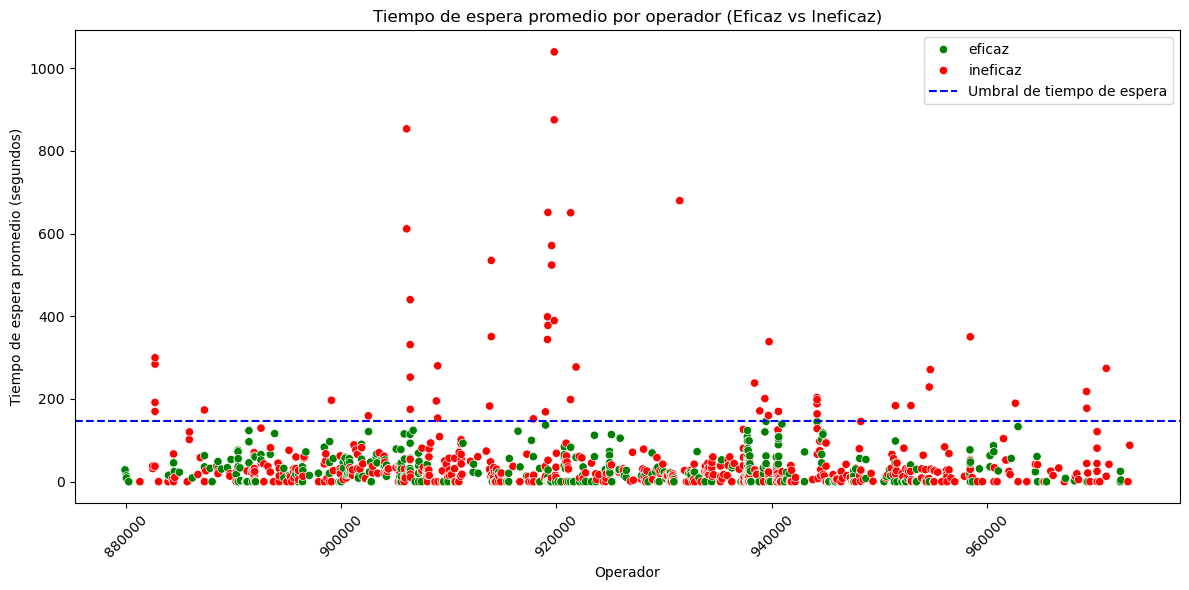

In [59]:
# Graficos de dispersion de tiempo de espera promedio por operador, diferenciando entre operadores eficaces e ineficaces
plt.figure(figsize=(12, 6))
sns.scatterplot(data=stats_by_operator_classified, x='operator_id', y='avg_waiting_time', hue='eficiencia', palette={'eficaz': 'green', 'ineficaz': 'red'})

# Dibujar linea horizontal del umbral de tiempo de espera
plt.axhline(y=waiting_time_threshold, color='blue', linestyle='--', label='Umbral de tiempo de espera')
plt.title('Tiempo de espera promedio por operador (Eficaz vs Ineficaz)')
plt.xlabel('Operador')
plt.ylabel('Tiempo de espera promedio (segundos)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

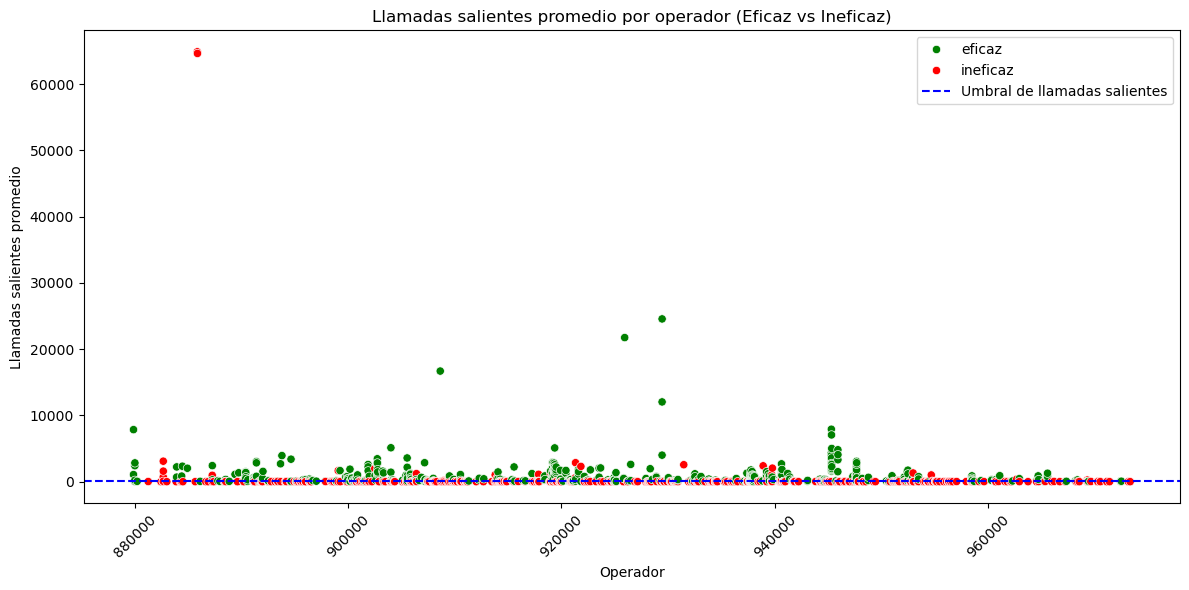

In [60]:
# Grafica de dispersion de llamadas salientes promedio por operador, diferenciando entre operadores eficaces e ineficaces
plt.figure(figsize=(12, 6))
sns.scatterplot(data=stats_by_operator_classified, x='operator_id', y='out_calls_count', hue='eficiencia', palette={'eficaz': 'green', 'ineficaz': 'red'})

# Dibujar linea horizontal del umbral de llamadas salientes
plt.axhline(y=out_calls_count_threshold, color='blue', linestyle='--', label='Umbral de llamadas salientes')
plt.title('Llamadas salientes promedio por operador (Eficaz vs Ineficaz)')
plt.xlabel('Operador')
plt.ylabel('Llamadas salientes promedio')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

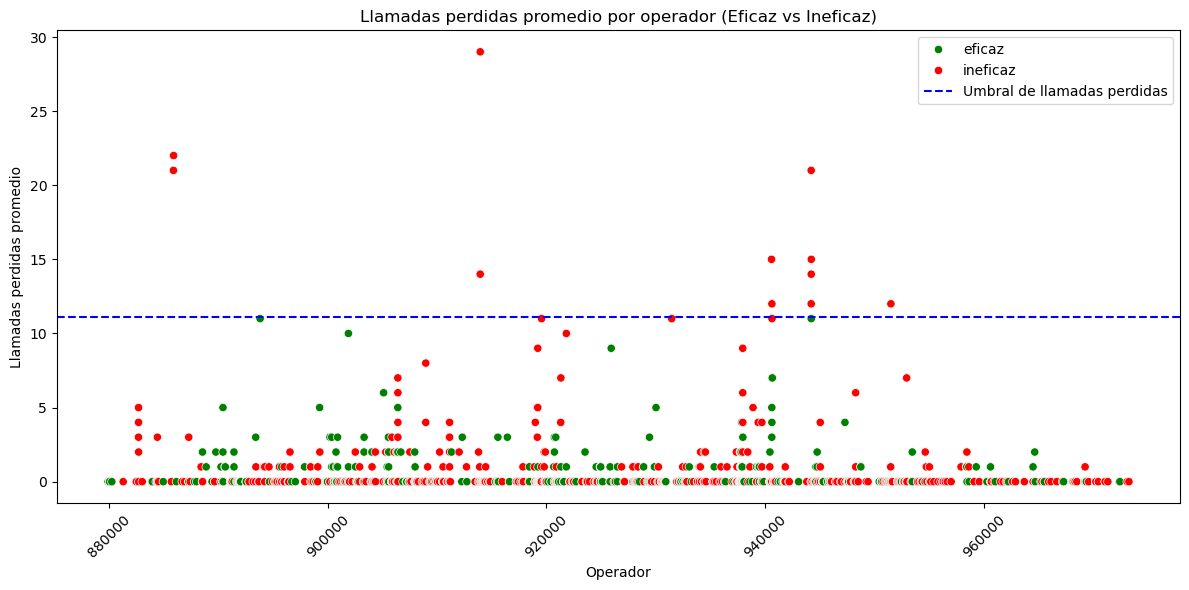

In [61]:
# Grafica comparativa de llamadas perdidas promedio por operador, diferenciando entre operadores eficaces e ineficaces
plt.figure(figsize=(12, 6))
sns.scatterplot(data=stats_by_operator_classified, x='operator_id', y='missed_calls', hue='eficiencia', palette={'eficaz': 'green', 'ineficaz': 'red'})

# Dibujar linea horizontal del umbral de llamadas perdidas
plt.axhline(y=missed_calls_threshold, color='blue', linestyle='--', label='Umbral de llamadas perdidas')
plt.title('Llamadas perdidas promedio por operador (Eficaz vs Ineficaz)')
plt.xlabel('Operador')
plt.ylabel('Llamadas perdidas promedio')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### == Observaciones de la clasificacion de operadores ==

Encontramos que de 1047 operadores, 565 fueron etiquetados como ineficaces. Debemos aclarar que esto es de acuerdo a los criterios que establecimos para clasificar los operadores. Consideramos que un operador debia cumplir al menos 1 de las 3 condiciones proporcionadas para ser considerado como ineficaz. Por el contrario 482 operadores fueron clasificados como eficaces, lo cual es menos de la mitad del total de operadores (los supervisores no estaran contentos.)

Ahora tenemos una tabla con metricas de los operadores y una etiqueta de clasificacion. Podemos crear 2 grupos "eficaz" e "ineficaz" y compararlos mediante una prueba estadistica.

## Parte 5. Pruebas de hipotesis estadisticas

Ahora tenemos una tabla llamada `stats_by_operator_classified` que nos da las metricas de rendimiento de cada operador y su clasificacion: eficaz si cumple los criterios que establecidos o ineficaz si esta por debajo de esos criterios. La tarea que nos queda es someter ambos grupos a una prueba estadistica para que nos pueda revelar con mayor rigurosidad si es verdad que exiten diferencias notables entre ambos grupos. Usaremos la metrica de tiempo de espera promedio para comparar los grupos y formular las hipotesis.

Planteamiento de la hipotesis:

- **Hipotesis Nula**: No hay diferencia significativa en el tiempo de espera promedio entre operadores eficaces e ineficaces.
- **Hipotesis Alternativa**: El tiempo de espera promedio entre operadores eficaces e ineficaces difiere significativamente.

Vamos a comparar las tres metricas de rendimiento que usamos para clasificar a los operadores en eficaces o ineficaces, esto con el fin de evaluar la validez de la clasificacion que hemos realizado. El valor para alpha lo vamos a establecer en `alpha=0.05`.

- Pruebas a realizar: prueba T de Student para muestras independientes y prueba estadistica de Mann-Whitney U
- Valor de alpha: `alpha=0.05`

In [62]:
# Separar operadores eficaces e ineficaces
operadores_eficaces = stats_by_operator_classified[stats_by_operator_classified['eficiencia'] == 'eficaz']
operadores_ineficaces = stats_by_operator_classified[stats_by_operator_classified['eficiencia'] == 'ineficaz']

#### 5.1 Prueba de hipotesis estadistica T de Student (Llamadas perdidas, Tiempo de espera prom., Volumen de llamadas)

In [63]:
# Prueba de hipotesis estadistica T de Student

# Crear un bucle para aplicar la prueba de hipótesis ttest_ind a cada una de las métricas (missed_calls, avg_waiting_time, out_calls_count) entre operadores eficaces e ineficaces
metrics = ['missed_calls', 'avg_waiting_time', 'out_calls_count']
alpha = 0.05

print("\n ================= Resultados de la Prueba de hipótesis T de Student para comparar métricas entre operadores eficaces e ineficaces ================ \n")

for metric in metrics:
    print(f"\nComparando la métrica: {metric}\n")
    
    # Operadores eficaces: media y desviacion estandar de la métrica
    print(f"Media de {metric} para operadores eficaces: {operadores_eficaces[metric].mean():.2f}")
    print(f"Desviación estándar de {metric} para operadores eficaces: {operadores_eficaces[metric].std():.2f}\n")
    
    # Operadores ineficaces: media y desviacion estandar de la métrica
    print(f"Media de {metric} para operadores ineficaces: {operadores_ineficaces[metric].mean():.2f}")
    print(f"Desviación estándar de {metric} para operadores ineficaces: {operadores_ineficaces[metric].std():.2f}\n")
    
    # Prueba estadistica ttest_ind
    results = st.ttest_ind(operadores_eficaces[metric], operadores_ineficaces[metric], equal_var=False)
    
    print('valor p: {:.5f}'.format(results.pvalue))
    
    if (results.pvalue < alpha):
        print(f"Rechazamos la hipótesis nula. Hay una diferencia estadísticamente significativa en {metric} entre operadores eficaces e ineficaces.")
    else:
        print(f"No podemos rechazar la hipótesis nula. No hay una diferencia estadísticamente significativa en {metric} entre operadores eficaces e ineficaces.")


 ================= Resultados de la Prueba de hipótesis T de Student para comparar métricas entre operadores eficaces e ineficaces ================ 


Comparando la métrica: missed_calls

Media de missed_calls para operadores eficaces: 0.54
Desviación estándar de missed_calls para operadores eficaces: 1.38

Media de missed_calls para operadores ineficaces: 0.80
Desviación estándar de missed_calls para operadores ineficaces: 2.76

valor p: 0.03967
Rechazamos la hipótesis nula. Hay una diferencia estadísticamente significativa en missed_calls entre operadores eficaces e ineficaces.

Comparando la métrica: avg_waiting_time

Media de avg_waiting_time para operadores eficaces: 26.39
Desviación estándar de avg_waiting_time para operadores eficaces: 32.48

Media de avg_waiting_time para operadores ineficaces: 51.42
Desviación estándar de avg_waiting_time para operadores ineficaces: 108.88

valor p: 0.00000
Rechazamos la hipótesis nula. Hay una diferencia estadísticamente significativa en avg

#### 5.2 Prueba de hipotesis estadistica Prueba Mann-Whitney U (Llamadas perdidas, Tiempo de espera prom, Volumen de llamadas)

In [64]:
# Prueba de hipotesis estadistica de Mann-Whitney U

# Crear un bucle para aplicar la prueba de hipótesis Mann-Whitney U a cada una de las métricas (missed_calls, avg_waiting_time, out_calls_count) entre operadores eficaces e ineficaces
metrics = ['missed_calls', 'avg_waiting_time', 'out_calls_count']
alpha = 0.05

print("\n ==== Resultados de la Prueba de hipótesis Mann-Whitney U para comparar métricas entre operadores eficaces e ineficaces ==== \n")

for metric in metrics:
    print(f"\nComparando la métrica: {metric}\n")
    
    # Prueba estadistica Mann-Whitney U
    results = st.mannwhitneyu(operadores_eficaces[metric], operadores_ineficaces[metric], alternative='two-sided')
    
    print('valor p: {:.5f}'.format(results.pvalue))
    
    if (results.pvalue < alpha):
        print(f"Rechazamos la hipótesis nula. Hay una diferencia estadísticamente significativa en {metric} entre operadores eficaces e ineficaces.")
    else:
        print(f"No podemos rechazar la hipótesis nula. No hay una diferencia estadísticamente significativa en {metric} entre operadores eficaces e ineficaces.")


 ==== Resultados de la Prueba de hipótesis Mann-Whitney U para comparar métricas entre operadores eficaces e ineficaces ==== 


Comparando la métrica: missed_calls

valor p: 0.26482
No podemos rechazar la hipótesis nula. No hay una diferencia estadísticamente significativa en missed_calls entre operadores eficaces e ineficaces.

Comparando la métrica: avg_waiting_time

valor p: 0.00031
Rechazamos la hipótesis nula. Hay una diferencia estadísticamente significativa en avg_waiting_time entre operadores eficaces e ineficaces.

Comparando la métrica: out_calls_count

valor p: 0.00000
Rechazamos la hipótesis nula. Hay una diferencia estadísticamente significativa en out_calls_count entre operadores eficaces e ineficaces.


### === Comentarios de resultados de las pruebas ===

Debido a que las metricas que evaluamos en general no siguen una distribución normal, la prueba de Mann-Whitney U es más adecuada para comparar las medias entre los grupos de operadores eficaces e ineficaces. Sin embargo decidimos aplicar ademas la prueba T de Student y los resultados fueron "similares". Ambas pruebas resultaron en que existe una diferencia significativa entre operarodes eficaces e ineficaces, excepto la prueba Mann-Whitney U para las llamadas perdidas. Sin embargo el resto de pruebas apoyan la clasificacion que realizamos. 

Con estos resultados tenemos un grado de seguridad mayor para afirmar que efectivamente hemos identificado la eficiencia de operadores mediante una evaluacion de sus metricas de rendimiento. Un poco mas de la mitad de los operadores evaluados resultaron tener alguna deficiencia en su desempeño, lo cual creemos que puede tomarse como una oportunidad para mejorar el rendimiento de los operadores.

## Paso 6. Conclusiones

El objetivo primordial de nuestro analisis era probar la nueva funcion que brinda datos para determinar la eficiencia de los operadores telefonicos. En esencia nuestra tarea era identificar operadores ineficaces mediante los datos proporcianados y comprobar la clasificacion de operadores mediante una prueba de hipotesis estadistica. A continuacion se enlistan las tareas realizadas para este analisis y algunos hallazgos encontrados.

- Los datos que nos proporcionaron nos ayudaron a crear una tabla con metricas clave de rendimiento de los operadores. 
- Durante el proceso hallamos datos "outliers", operadores con tiempos de espera demasiado altos y una cantidad de llamadas realizadas exagerada. Sin embargo, dado que debiamos evaluar a todos los operadores, mantuvimos estos datos.
- Posteriormente determinamos umbrales de rendimiento para numero de llamadas perdidas (solo llamadas entrantes), tiempo de espera promedio (por operador) y volumen de llamadas realizadas (solo llamadas salientes), lo que nos permitio clasificar a los operadores en dos categorias: Eficaz e Ineficaz.
- Una vez pudimos clasificar a los operadores en dos grupos separados e independientes, aplicamos pruebas estadisticas a los datos de rendimiento de los operadores. Esto con el fin de comprobar con mayor rigurosidad la validez de la clasificacion que realizamos.
- Los resultados nos brindaron mayor certeza para afirmar que efectivamente los operadores identificados son ineficaces, y que digamos, tienen oportunidades de mejora.

Por lo tanto podemos afirmar con un alto grado de seguridad que hemos identificado estos operadores como ineficaces y que la nueva funcion es "eficaz" para realizar esta tarea.